# ML Bancario 3.0 — Pipeline con Comparación Secuencial vs Paralelo

Este notebook implementa el pipeline completo del proyecto con tres mejoras clave:

1. **Grid de 4 configuraciones de hiperparámetros por modelo** (LightGBM y XGBoost), entrenadas en paralelo.
2. **Preprocesamiento paralelizado** (imputación y escalado por bloques en paralelo).
3. **Comparación de tiempos** entre ejecución secuencial y paralela, con visualización.

In [1]:
import pandas as pd
import numpy as np
import time
import joblib
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import roc_auc_score, f1_score, classification_report

## Fases 1-4: Carga y preprocesamiento

Mantenemos las funciones originales para las fases 1, 2 y 4. La fase 3 (preprocesamiento) tiene **dos versiones**: secuencial y paralela. La paralela ejecuta en hilos separados los tres bloques de imputación (categóricas, continuas, enteras), aprovechando que son tareas independientes.

In [2]:
# --- FASE 1: Carga y corrección inicial ---
def cargar_y_corregir_datos(ruta_train, ruta_test, col_anomala=None, valor_anomalo=None, verbose=True):
    """Carga los datos y corrige valores centinela reemplazándolos por nulos."""
    if verbose:
        print("=" * 60)
        print(" FASE 1: CARGA DE DATOS Y CORRECCIÓN DE ANOMALÍAS")
        print("=" * 60)
    
    train = pd.read_csv(ruta_train)
    test = pd.read_csv(ruta_test)
    
    if col_anomala and valor_anomalo is not None:
        train[col_anomala] = train[col_anomala].replace(valor_anomalo, np.nan)
        test[col_anomala] = test[col_anomala].replace(valor_anomalo, np.nan)
        if verbose:
            print(f" Anomalía corregida en la columna '{col_anomala}'.")
    if verbose:
        print(f"Tamaño Train: {train.shape} | Tamaño Test: {test.shape}")
    return train, test

# --- FASE 2: Unión y limpieza de nulos excesivos ---
def limpiar_nulos_excesivos(train, test, umbral_obs=0.5, umbral_attr=0.6, auto_eliminar=True, verbose=True):
    """Une los datasets y elimina filas/columnas con demasiados nulos."""
    if verbose:
        print("\n" + "=" * 60)
        print(" FASE 2: LIMPIEZA DE NULOS EXCESIVOS")
        print("=" * 60)
    
    train_copy = train.copy()
    test_copy = test.copy()
    test_copy['TARGET'] = 2 #se le asigna un valor de target imaginario para poder identificar los datos test
    
    df = pd.concat([train_copy, test_copy], axis=0, ignore_index=True)
    
    predictoras = df.drop(columns=['TARGET'])
    n_obs, n_attr = predictoras.shape
    
    obs_muchos_vacios = (predictoras.isnull().sum(axis=1) / n_attr) >= umbral_obs
    if obs_muchos_vacios.sum() > 0 and auto_eliminar:
        df = df.loc[~obs_muchos_vacios]
        if verbose:
            print(f"Se eliminaron {obs_muchos_vacios.sum()} filas por exceso de nulos.")
        
    attr_muchos_vacios = (predictoras.isnull().sum(axis=0) / n_obs) >= umbral_attr
    if attr_muchos_vacios.sum() > 0 and auto_eliminar:
        cols_a_mantener = predictoras.columns[~attr_muchos_vacios].tolist() + ['TARGET']
        df = df[cols_a_mantener]
        if verbose:
            print(f"Se eliminaron {attr_muchos_vacios.sum()} columnas por exceso de nulos.")
    if verbose:
        print(f"Dimensiones tras limpieza: {df.shape}")
    return df

In [3]:
# --- Bloques individuales de imputación (paralelizables) ---
def _imputar_categoricas(df, cols_categoricas):
    """Imputa categóricas con 'Desconocido' y las convierte a tipo category."""
    if not cols_categoricas:
        return pd.DataFrame()
    imputer_cat = SimpleImputer(strategy='constant', fill_value='Desconocido')
    bloque = pd.DataFrame(
        imputer_cat.fit_transform(df[cols_categoricas]),
        columns=cols_categoricas,
        index=df.index
    )
    for col in cols_categoricas:
        bloque[col] = bloque[col].astype('category')
    return bloque

def _imputar_y_escalar_continuas(df, cols_continuas):
    """Imputa continuas con mediana y escala con RobustScaler."""
    if not cols_continuas:
        return pd.DataFrame()
    imputer_num = SimpleImputer(strategy='median')
    valores_imputados = imputer_num.fit_transform(df[cols_continuas])
    scaler = RobustScaler()
    valores_escalados = scaler.fit_transform(valores_imputados)
    bloque = pd.DataFrame(valores_escalados, columns=cols_continuas, index=df.index)
    return bloque

def _imputar_enteras(df, cols_enteras):
    """Imputa enteras con mediana y fuerza tipo Int64."""
    if not cols_enteras:
        return pd.DataFrame()
    imputer_int = SimpleImputer(strategy='median')
    valores = imputer_int.fit_transform(df[cols_enteras])
    bloque = pd.DataFrame(valores, columns=cols_enteras, index=df.index)
    bloque = bloque.round().astype('Int64')
    return bloque

# --- FASE 3: Preprocesamiento — versión SECUENCIAL ---
def preprocesar_datos_secuencial(df_unido, cols_enteras_conocidas=None, verbose=True):
    """Imputa, escala y da formato a las variables — ejecución secuencial."""
    if verbose:
        print("\n" + "=" * 60)
        print(" FASE 3 (SECUENCIAL): PREPROCESAMIENTO")
        print("=" * 60)
    
    df = df_unido.copy()
    if cols_enteras_conocidas is None:
        cols_enteras_conocidas = []
    
    cols_enteras = [col for col in cols_enteras_conocidas if col in df.columns]
    cols_numericas = df.select_dtypes(include=['number']).columns.tolist()
    if 'TARGET' in cols_numericas:
        cols_numericas.remove('TARGET')
    cols_continuas = [col for col in cols_numericas if col not in cols_enteras]
    cols_categoricas = df.select_dtypes(exclude=['number']).columns.tolist()
    
    # Ejecución secuencial: una tarea tras otra
    bloque_cat = _imputar_categoricas(df, cols_categoricas)
    bloque_cont = _imputar_y_escalar_continuas(df, cols_continuas)
    bloque_int = _imputar_enteras(df, cols_enteras)
    
    # Reensamblar
    if not bloque_cat.empty:
        df[cols_categoricas] = bloque_cat
    if not bloque_cont.empty:
        df[cols_continuas] = bloque_cont
    if not bloque_int.empty:
        df[cols_enteras] = bloque_int
    
    if verbose:
        print(f" {len(cols_categoricas)} categóricas, {len(cols_continuas)} continuas, {len(cols_enteras)} enteras procesadas.")
    return df

# --- FASE 3: Preprocesamiento — versión PARALELA ---
def preprocesar_datos_paralelo(df_unido, cols_enteras_conocidas=None, verbose=True):
    """Imputa y escala en paralelo los tres bloques de columnas (categóricas, continuas, enteras)."""
    if verbose:
        print("\n" + "=" * 60)
        print(" FASE 3 (PARALELO): PREPROCESAMIENTO")
        print("=" * 60)
    
    df = df_unido.copy()
    if cols_enteras_conocidas is None:
        cols_enteras_conocidas = []
    
    cols_enteras = [col for col in cols_enteras_conocidas if col in df.columns]
    cols_numericas = df.select_dtypes(include=['number']).columns.tolist()
    if 'TARGET' in cols_numericas:
        cols_numericas.remove('TARGET')
    cols_continuas = [col for col in cols_numericas if col not in cols_enteras]
    cols_categoricas = df.select_dtypes(exclude=['number']).columns.tolist()
    
    # Las tres tareas son independientes → paralelismo de tareas
    resultados = joblib.Parallel(n_jobs=3, backend='threading')([
        joblib.delayed(_imputar_categoricas)(df, cols_categoricas),
        joblib.delayed(_imputar_y_escalar_continuas)(df, cols_continuas),
        joblib.delayed(_imputar_enteras)(df, cols_enteras)
    ])
    bloque_cat, bloque_cont, bloque_int = resultados
    
    if not bloque_cat.empty:
        df[cols_categoricas] = bloque_cat
    if not bloque_cont.empty:
        df[cols_continuas] = bloque_cont
    if not bloque_int.empty:
        df[cols_enteras] = bloque_int
    
    if verbose:
        print(f" {len(cols_categoricas)} categóricas, {len(cols_continuas)} continuas, {len(cols_enteras)} enteras procesadas.")
    return df

# --- FASE 4: Separación de Sets ---
def preparar_sets_entrenamiento(df_procesado, test_size=0.20, random_state=42, verbose=True):
    """Separa el dataset en train, validación y test final."""
    if verbose:
        print("\n" + "=" * 60)
        print(" FASE 4: SEPARACIÓN DE SETS DE DATOS")
        print("=" * 60)
    
    train_limpio = df_procesado[df_procesado['TARGET'].isin([0, 1])].copy()
    test_limpio = df_procesado[df_procesado['TARGET'] == 2].copy()

    X = train_limpio.drop(columns=['TARGET'])
    y = train_limpio['TARGET'].astype(int)
    X_test_final = test_limpio.drop(columns=['TARGET'])

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    if verbose:
        print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test Final: {X_test_final.shape}")
    return X_train, X_val, y_train, y_val, X_test_final

## Funciones de entrenamiento

Cada función entrena un modelo con un set de hiperparámetros y devuelve el modelo, las métricas y el tiempo. **Importante:** las funciones imprimen las métricas al final, lo que soluciona el bug original donde las métricas no se mostraban después del entrenamiento paralelo.

In [4]:
def entrenar_lightgbm(X_train, y_train, X_val, y_val, config_id='LGB-default',
                       learning_rate=0.05, num_leaves=31, num_boost_round=1000,
                       n_jobs=-1):
    """Entrena LightGBM con la configuración indicada y devuelve modelo, métricas y tiempo."""
    t0 = time.time()
    
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'learning_rate': learning_rate,
        'num_leaves': num_leaves,
        'n_jobs': n_jobs,
        'is_unbalance': True,
        'verbose': -1
    }

    train_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

    callbacks = [
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=0)
    ]

    modelo_lgb = lgb.train(
        params, train_data,
        num_boost_round=num_boost_round,
        valid_sets=[train_data, val_data],
        callbacks=callbacks
    )

    y_pred_prob = modelo_lgb.predict(X_val)
    y_pred_class = (y_pred_prob > 0.5).astype(int)

    auc = roc_auc_score(y_val, y_pred_prob)
    f1 = f1_score(y_val, y_pred_class)
    elapsed = time.time() - t0
    
    print(f"  [{config_id}] LightGBM | AUC: {auc:.4f} | F1: {f1:.4f} | Tiempo: {elapsed:.2f}s")
    
    return {
        'config_id': config_id,
        'modelo': 'LightGBM',
        'params': {'learning_rate': learning_rate, 'num_leaves': num_leaves},
        'roc_auc': auc,
        'f1_score': f1,
        'tiempo': elapsed
    }

def entrenar_xgboost(X_train, y_train, X_val, y_val, config_id='XGB-default',
                      learning_rate=0.05, max_depth=6, num_boost_round=1000,
                      scale_weight=1.0, n_jobs=-1):
    """Entrena XGBoost con la configuración indicada y devuelve modelo, métricas y tiempo."""
    t0 = time.time()
    
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'tree_method': 'hist',
        'learning_rate': learning_rate,
        'max_depth': max_depth,
        'n_jobs': n_jobs,
        'scale_pos_weight': scale_weight,
        'random_state': 42
    }

    dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
    dval = xgb.DMatrix(X_val, label=y_val, enable_categorical=True)

    evals = [(dtrain, 'entrenamiento'), (dval, 'validacion')]

    modelo_xgb = xgb.train(
        params, dtrain,
        num_boost_round=num_boost_round,
        evals=evals,
        early_stopping_rounds=50,
        verbose_eval=False
    )

    y_pred_prob = modelo_xgb.predict(dval)
    y_pred_class = (y_pred_prob > 0.5).astype(int)

    auc = roc_auc_score(y_val, y_pred_prob)
    f1 = f1_score(y_val, y_pred_class)
    elapsed = time.time() - t0
    
    print(f"  [{config_id}] XGBoost  | AUC: {auc:.4f} | F1: {f1:.4f} | Tiempo: {elapsed:.2f}s")
    
    return {
        'config_id': config_id,
        'modelo': 'XGBoost',
        'params': {'learning_rate': learning_rate, 'max_depth': max_depth},
        'roc_auc': auc,
        'f1_score': f1,
        'tiempo': elapsed
    }

## Definición del grid de hiperparámetros

8 entrenamientos en total: 4 configuraciones × 2 modelos.

In [5]:
# 4 configuraciones de hiperparámetros para cada modelo
configs_lgb = [
    {'config_id': 'LGB-1', 'learning_rate': 0.05, 'num_leaves': 31},
    {'config_id': 'LGB-2', 'learning_rate': 0.05, 'num_leaves': 63},
    {'config_id': 'LGB-3', 'learning_rate': 0.10, 'num_leaves': 31},
    {'config_id': 'LGB-4', 'learning_rate': 0.01, 'num_leaves': 127},
]

configs_xgb = [
    {'config_id': 'XGB-1', 'learning_rate': 0.05, 'max_depth': 6},
    {'config_id': 'XGB-2', 'learning_rate': 0.05, 'max_depth': 8},
    {'config_id': 'XGB-3', 'learning_rate': 0.10, 'max_depth': 6},
    {'config_id': 'XGB-4', 'learning_rate': 0.01, 'max_depth': 10},
]

print(f"Total de modelos a entrenar: {len(configs_lgb) + len(configs_xgb)}")

Total de modelos a entrenar: 8


## Carga del dataset y separación de sets

In [6]:
RUTA_TRAIN = 'application_train.csv'
RUTA_TEST = 'application_test.csv'
COLUMNA_ANOMALA = 'DAYS_EMPLOYED'
VALOR_ANOMALO = 365243

COLUMNAS_QUE_DEBEN_SER_ENTERAS = [
    'CNT_FAM_MEMBERS', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
    'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'DAYS_LAST_PHONE_CHANGE',
    'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
    'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR',
    'DAYS_EMPLOYED'
]

---
## EJECUCIÓN SECUENCIAL

Todo el pipeline se corre sin paralelismo: preprocesamiento secuencial y modelos entrenados uno tras otro con un solo núcleo (`n_jobs=1`).

In [7]:
print("\n" + "#" * 60)
print("# EJECUCIÓN SECUENCIAL")
print("#" * 60)

tiempos_secuencial = {}
t_total_seq_start = time.time()

# --- Carga ---
t0 = time.time()
df_train_raw_s, df_test_raw_s = cargar_y_corregir_datos(
    RUTA_TRAIN, RUTA_TEST, COLUMNA_ANOMALA, VALOR_ANOMALO
)
tiempos_secuencial['Carga'] = time.time() - t0

# --- Limpieza ---
t0 = time.time()
df_unificado_s = limpiar_nulos_excesivos(df_train_raw_s, df_test_raw_s, auto_eliminar=True)
tiempos_secuencial['Limpieza'] = time.time() - t0

# --- Preprocesamiento (secuencial) ---
t0 = time.time()
df_listo_s = preprocesar_datos_secuencial(df_unificado_s, cols_enteras_conocidas=COLUMNAS_QUE_DEBEN_SER_ENTERAS)
tiempos_secuencial['Preprocesamiento'] = time.time() - t0

# --- Split ---
t0 = time.time()
X_train_s, X_val_s, y_train_s, y_val_s, X_test_final_s = preparar_sets_entrenamiento(df_listo_s)
tiempos_secuencial['Split'] = time.time() - t0

peso_clase_positiva_s = sum(y_train_s == 0) / sum(y_train_s == 1)

# --- Entrenamiento secuencial: 8 modelos uno tras otro con n_jobs=1 ---
print("\n" + "=" * 60)
print(" FASE 5 (SECUENCIAL): ENTRENAMIENTO DE 8 MODELOS")
print("=" * 60)
t0 = time.time()
resultados_secuencial = []

for cfg in configs_lgb:
    res = entrenar_lightgbm(X_train_s, y_train_s, X_val_s, y_val_s,
                             n_jobs=1, **cfg)
    resultados_secuencial.append(res)

for cfg in configs_xgb:
    res = entrenar_xgboost(X_train_s, y_train_s, X_val_s, y_val_s,
                            scale_weight=peso_clase_positiva_s, n_jobs=1, **cfg)
    resultados_secuencial.append(res)

tiempos_secuencial['Entrenamiento'] = time.time() - t0
tiempos_secuencial['TOTAL'] = time.time() - t_total_seq_start

print("\n" + "=" * 60)
print(" TIEMPOS SECUENCIALES")
print("=" * 60)
for fase, t in tiempos_secuencial.items():
    print(f"  {fase:<20s} {t:>8.2f}s")


############################################################
# EJECUCIÓN SECUENCIAL
############################################################
 FASE 1: CARGA DE DATOS Y CORRECCIÓN DE ANOMALÍAS
 Anomalía corregida en la columna 'DAYS_EMPLOYED'.
Tamaño Train: (307511, 122) | Tamaño Test: (48744, 121)

 FASE 2: LIMPIEZA DE NULOS EXCESIVOS
Se eliminaron 14 filas por exceso de nulos.
Se eliminaron 17 columnas por exceso de nulos.
Dimensiones tras limpieza: (356241, 105)

 FASE 3 (SECUENCIAL): PREPROCESAMIENTO
 15 categóricas, 76 continuas, 13 enteras procesadas.

 FASE 4: SEPARACIÓN DE SETS DE DATOS
Train: (245998, 104) | Val: (61500, 104) | Test Final: (48743, 104)

🧠 FASE 5 (SECUENCIAL): ENTRENAMIENTO DE 8 MODELOS
  [LGB-1] LightGBM | AUC: 0.7597 | F1: 0.2730 | Tiempo: 46.05s
  [LGB-2] LightGBM | AUC: 0.7591 | F1: 0.2780 | Tiempo: 54.81s
  [LGB-3] LightGBM | AUC: 0.7585 | F1: 0.2701 | Tiempo: 24.84s
  [LGB-4] LightGBM | AUC: 0.7594 | F1: 0.2837 | Tiempo: 236.40s
  [XGB-1] XGBoost  | AU

---
## EJECUCIÓN PARALELA

El pipeline aprovecha paralelismo en tres niveles:
1. **Preprocesamiento paralelo:** las 3 tareas de imputación (categóricas, continuas, enteras) corren en hilos separados.
2. **Paralelismo de tareas:** los 8 entrenamientos (4 LGB + 4 XGB) se lanzan simultáneamente con `joblib.Parallel`.
3. **Paralelismo de datos (OpenMP):** dentro de cada entrenamiento, LightGBM y XGBoost usan todos los núcleos disponibles vía `n_jobs=-1`.

In [8]:
print("\n" + "#" * 60)
print("# EJECUCIÓN PARALELA")
print("#" * 60)

tiempos_paralelo = {}
t_total_par_start = time.time()

# --- Carga ---
t0 = time.time()
df_train_raw_p, df_test_raw_p = cargar_y_corregir_datos(
    RUTA_TRAIN, RUTA_TEST, COLUMNA_ANOMALA, VALOR_ANOMALO
)
tiempos_paralelo['Carga'] = time.time() - t0

# --- Limpieza ---
t0 = time.time()
df_unificado_p = limpiar_nulos_excesivos(df_train_raw_p, df_test_raw_p, auto_eliminar=True)
tiempos_paralelo['Limpieza'] = time.time() - t0

# --- Preprocesamiento (paralelo) ---
t0 = time.time()
df_listo_p = preprocesar_datos_paralelo(df_unificado_p, cols_enteras_conocidas=COLUMNAS_QUE_DEBEN_SER_ENTERAS)
tiempos_paralelo['Preprocesamiento'] = time.time() - t0

# --- Split ---
t0 = time.time()
X_train_p, X_val_p, y_train_p, y_val_p, X_test_final_p = preparar_sets_entrenamiento(df_listo_p)
tiempos_paralelo['Split'] = time.time() - t0

peso_clase_positiva_p = sum(y_train_p == 0) / sum(y_train_p == 1)

# --- Entrenamiento paralelo: las 8 configuraciones lanzadas simultáneamente ---
print("\n" + "=" * 60)
print(" FASE 5 (PARALELO): 8 MODELOS LANZADOS SIMULTÁNEAMENTE")
print("=" * 60)
t0 = time.time()

tareas = []
for cfg in configs_lgb:
    tareas.append(joblib.delayed(entrenar_lightgbm)(
        X_train_p, y_train_p, X_val_p, y_val_p, n_jobs=-1, **cfg
    ))
for cfg in configs_xgb:
    tareas.append(joblib.delayed(entrenar_xgboost)(
        X_train_p, y_train_p, X_val_p, y_val_p,
        scale_weight=peso_clase_positiva_p, n_jobs=-1, **cfg
    ))

resultados_paralelo = joblib.Parallel(n_jobs=8, backend='threading')(tareas)

tiempos_paralelo['Entrenamiento'] = time.time() - t0
tiempos_paralelo['TOTAL'] = time.time() - t_total_par_start

print("\n" + "=" * 60)
print(" TIEMPOS PARALELOS")
print("=" * 60)
for fase, t in tiempos_paralelo.items():
    print(f"  {fase:<20s} {t:>8.2f}s")


############################################################
# EJECUCIÓN PARALELA
############################################################
 FASE 1: CARGA DE DATOS Y CORRECCIÓN DE ANOMALÍAS
 Anomalía corregida en la columna 'DAYS_EMPLOYED'.
Tamaño Train: (307511, 122) | Tamaño Test: (48744, 121)

 FASE 2: LIMPIEZA DE NULOS EXCESIVOS
Se eliminaron 14 filas por exceso de nulos.
Se eliminaron 17 columnas por exceso de nulos.
Dimensiones tras limpieza: (356241, 105)

 FASE 3 (PARALELO): PREPROCESAMIENTO
 15 categóricas, 76 continuas, 13 enteras procesadas.

 FASE 4: SEPARACIÓN DE SETS DE DATOS
Train: (245998, 104) | Val: (61500, 104) | Test Final: (48743, 104)

 FASE 5 (PARALELO): 8 MODELOS LANZADOS SIMULTÁNEAMENTE
  [XGB-3] XGBoost  | AUC: 0.7538 | F1: 0.2783 | Tiempo: 80.63s
  [XGB-2] XGBoost  | AUC: 0.7472 | F1: 0.2787 | Tiempo: 105.47s
  [XGB-1] XGBoost  | AUC: 0.7557 | F1: 0.2787 | Tiempo: 119.96s
  [LGB-3] LightGBM | AUC: 0.7585 | F1: 0.2701 | Tiempo: 126.13s
  [LGB-1] LightGBM |

## Resumen de métricas y speedup

In [9]:
# Tabla resumen de métricas (versión paralela)
df_resultados = pd.DataFrame(resultados_paralelo)
print("\n" + "=" * 60)
print(" RESULTADOS DE LOS 8 MODELOS (versión paralela)")
print("=" * 60)
print(df_resultados[['config_id', 'modelo', 'roc_auc', 'f1_score', 'tiempo']].to_string(index=False))

mejor = df_resultados.loc[df_resultados['roc_auc'].idxmax()]
print(f"\n Mejor modelo: {mejor['config_id']} ({mejor['modelo']}) con AUC={mejor['roc_auc']:.4f}")

# Cálculo del speedup
print("\n" + "=" * 60)
print(" SPEEDUP POR FASE (Secuencial / Paralelo)")
print("=" * 60)
for fase in tiempos_secuencial.keys():
    t_seq = tiempos_secuencial[fase]
    t_par = tiempos_paralelo[fase]
    speedup = t_seq / t_par if t_par > 0 else 0
    print(f"  {fase:<20s} secuencial={t_seq:>7.2f}s | paralelo={t_par:>7.2f}s | speedup={speedup:>5.2f}x")


 RESULTADOS DE LOS 8 MODELOS (versión paralela)
config_id   modelo  roc_auc  f1_score     tiempo
    LGB-1 LightGBM 0.759701  0.272966 149.338649
    LGB-2 LightGBM 0.759121  0.278016 169.154759
    LGB-3 LightGBM 0.758506  0.270140 126.132041
    LGB-4 LightGBM 0.759365  0.283655 370.869931
    XGB-1  XGBoost 0.755748  0.278735 119.955574
    XGB-2  XGBoost 0.747241  0.278735 105.472837
    XGB-3  XGBoost 0.753827  0.278340  80.625805
    XGB-4  XGBoost 0.739068  0.278931 216.241963

 Mejor modelo: LGB-1 (LightGBM) con AUC=0.7597

 SPEEDUP POR FASE (Secuencial / Paralelo)
  Carga                secuencial=   6.94s | paralelo=   6.63s | speedup= 1.05x
  Limpieza             secuencial=   3.24s | paralelo=   2.80s | speedup= 1.16x
  Preprocesamiento     secuencial=  11.34s | paralelo=   8.17s | speedup= 1.39x
  Split                secuencial=   1.30s | paralelo=   1.29s | speedup= 1.00x
  Entrenamiento        secuencial= 864.44s | paralelo= 370.93s | speedup= 2.33x
  TOTAL            

## Visualización: comparación de tiempos

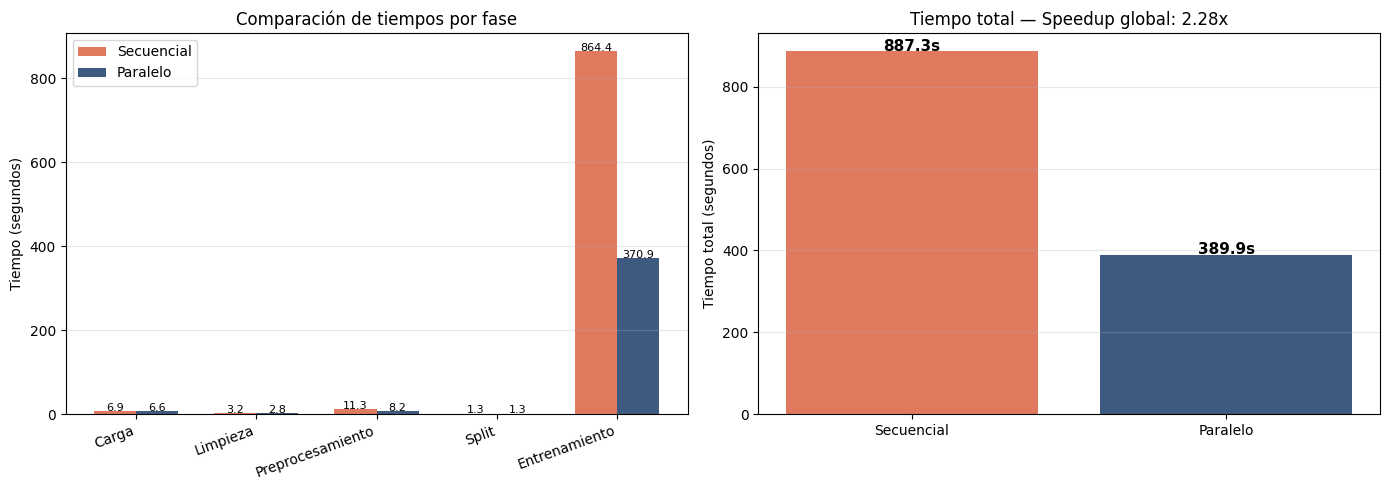


 Gráfico guardado como 'comparacion_tiempos.png'


In [10]:
# Datos para los gráficos
fases = [f for f in tiempos_secuencial.keys() if f != 'TOTAL']
tiempos_seq = [tiempos_secuencial[f] for f in fases]
tiempos_par = [tiempos_paralelo[f] for f in fases]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: barras agrupadas por fase ---
x = np.arange(len(fases))
ancho = 0.35
ax1 = axes[0]
ax1.bar(x - ancho/2, tiempos_seq, ancho, label='Secuencial', color='#E07A5F')
ax1.bar(x + ancho/2, tiempos_par, ancho, label='Paralelo', color='#3D5A80')
ax1.set_xticks(x)
ax1.set_xticklabels(fases, rotation=20, ha='right')
ax1.set_ylabel('Tiempo (segundos)')
ax1.set_title('Comparación de tiempos por fase')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Etiquetas con el valor en cada barra
for i, (s, p) in enumerate(zip(tiempos_seq, tiempos_par)):
    ax1.text(i - ancho/2, s + 0.5, f'{s:.1f}', ha='center', fontsize=8)
    ax1.text(i + ancho/2, p + 0.5, f'{p:.1f}', ha='center', fontsize=8)

# --- Gráfico 2: tiempo total y speedup global ---
ax2 = axes[1]
modos = ['Secuencial', 'Paralelo']
totales = [tiempos_secuencial['TOTAL'], tiempos_paralelo['TOTAL']]
colores = ['#E07A5F', '#3D5A80']
barras = ax2.bar(modos, totales, color=colores)
ax2.set_ylabel('Tiempo total (segundos)')
speedup_total = tiempos_secuencial['TOTAL'] / tiempos_paralelo['TOTAL']
ax2.set_title(f'Tiempo total — Speedup global: {speedup_total:.2f}x')
ax2.grid(axis='y', alpha=0.3)
for barra, valor in zip(barras, totales):
    ax2.text(barra.get_x() + barra.get_width()/2, valor + 0.5,
             f'{valor:.1f}s', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('comparacion_tiempos.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\n Gráfico guardado como 'comparacion_tiempos.png'")

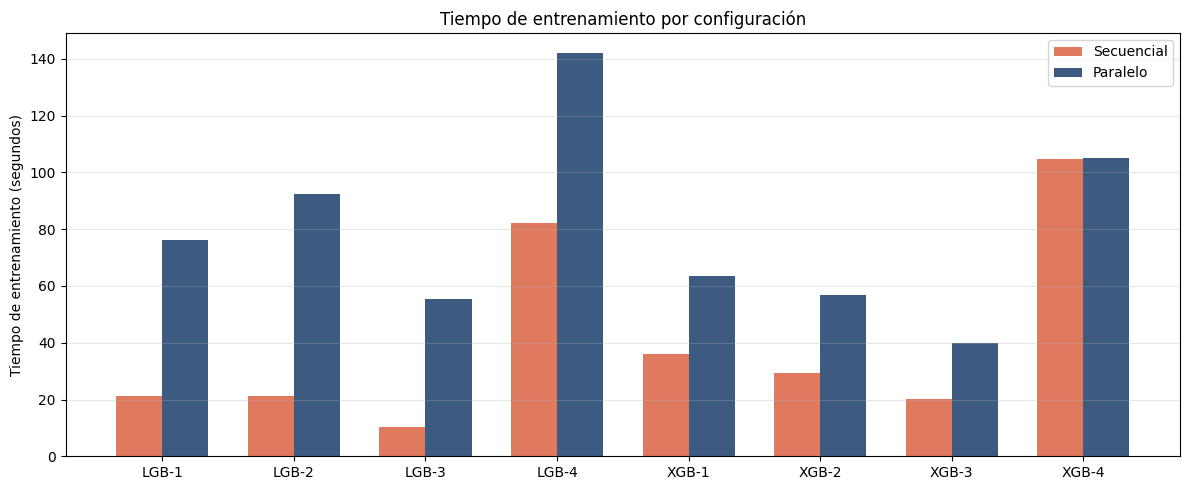

In [11]:
# Gráfico extra: tiempo individual de cada modelo (paralelo vs secuencial)
df_seq = pd.DataFrame(resultados_secuencial)[['config_id', 'tiempo']].rename(columns={'tiempo': 'secuencial'})
df_par = pd.DataFrame(resultados_paralelo)[['config_id', 'tiempo']].rename(columns={'tiempo': 'paralelo'})
df_comp = df_seq.merge(df_par, on='config_id')

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_comp))
ancho = 0.35
ax.bar(x - ancho/2, df_comp['secuencial'], ancho, label='Secuencial', color='#E07A5F')
ax.bar(x + ancho/2, df_comp['paralelo'], ancho, label='Paralelo', color='#3D5A80')
ax.set_xticks(x)
ax.set_xticklabels(df_comp['config_id'], rotation=0)
ax.set_ylabel('Tiempo de entrenamiento (segundos)')
ax.set_title('Tiempo de entrenamiento por configuración')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('tiempo_por_modelo.png', dpi=120, bbox_inches='tight')
plt.show()